In [1]:
import torch 
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import math
import matplotlib.pyplot as plt

In [2]:
# Define the execution device dynamically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
dataset = './dataset/jena_climate_2009_2016.csv'
train_size = 0.65
val_size = 0.80
batch_size = 64
seq_len = 720
output_len = 24
d_model = 128
d_ff = 128
no_of_encoder_layers = 3
no_of_heads = 4
input_features = 14

In [4]:
# Reading data from csv file
df = pd.read_csv(dataset)
df = df.drop(columns = "Date Time")
df = df.groupby(df.index // 6).mean()
data = df.to_numpy()

# Splitting data into train, val, test datasets
data_len = len(data)

train_data = data[0:int(train_size*data_len)]
val_data = data[int(train_size*data_len):int(val_size*data_len)]
test_data = data[int(val_size*data_len)::]

scalar = StandardScaler()
train_data = scalar.fit_transform(train_data)
val_data = scalar.transform(val_data)
test_data = scalar.transform(test_data)

In [5]:
# Creating a custom Dataset class for our usecase
class JenaClimateData(Dataset):
    def __init__(self, dataset, seq_len, output_len):
        self.dataset = dataset
        self.seq_len = seq_len
        self.output_len = output_len
    def __getitem__(self, idx):
        X = self.dataset[idx:idx+self.seq_len, :]
        y = self.dataset[idx+self.seq_len:idx+self.seq_len+self.output_len, 0]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.dataset)-self.seq_len-self.output_len+1

In [6]:
train_dataset = JenaClimateData(train_data, seq_len, output_len)
val_dataset = JenaClimateData(val_data, seq_len, output_len)
test_dataset = JenaClimateData(test_data, seq_len, output_len)

# Creating DataLoader Objects of batch size 64
train_dl = DataLoader(train_dataset, batch_size=batch_size)
val_dl = DataLoader(val_dataset, batch_size=batch_size)
test_dl = DataLoader(test_dataset, batch_size=batch_size)

## Transformer 
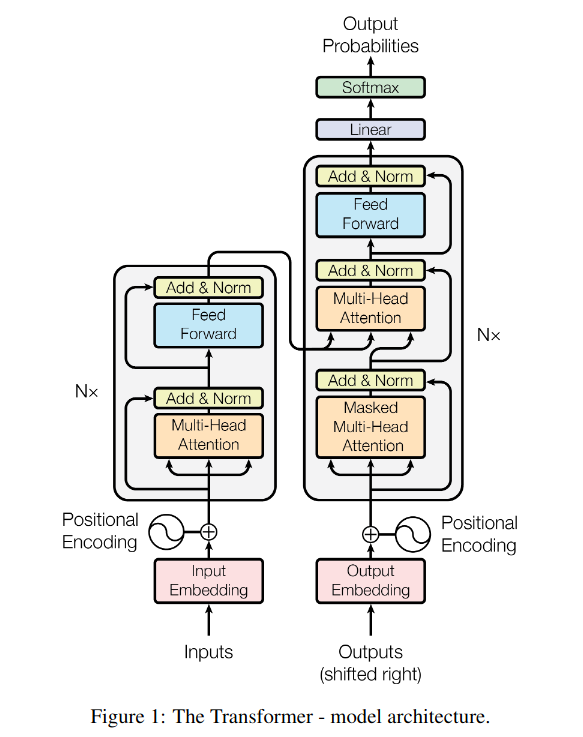

### Input Projection
```
Every timestep contains Temperature, Humidity, Pressure, etc (14 features).
We must convert 14 features into 128-dimensional embedding
Like word embeddings.
```

In [7]:
class InputProjection(nn.Module):
    def __init__(self, input_features, d_model):
        super().__init__()
        self.projection = nn.Linear(input_features, d_model)
    def forward(self, x):
        x = self.projection(x)
        return x

## Sinusoidal Encoding
```text
Our transformer has no reccurence so we inject some information about the relative or absolute positions to the input embeddings
Positional Encoding have the same dimension as the embeddings.
We use sin and cos to provide independent signals at same frequency to make model infer relative position differences
```

In [8]:
class SinusoidalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()

        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe = torch.zeros(max_len, d_model)

        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

## Multi-Head Attention 
```
We divide the dimensions of the model into multiple heads. We compute the scaled dot-product attentions of the heads in parallel. 

Concatenate the heads along features. This is just a concatenation, this doesnt help relating multiple features so we use a Fully Connected Layer to capture the relationships between all features.

Why Scaled dot-product attention ?
Prevent very large dot products that make the softmax saturate and gradients become small.

```

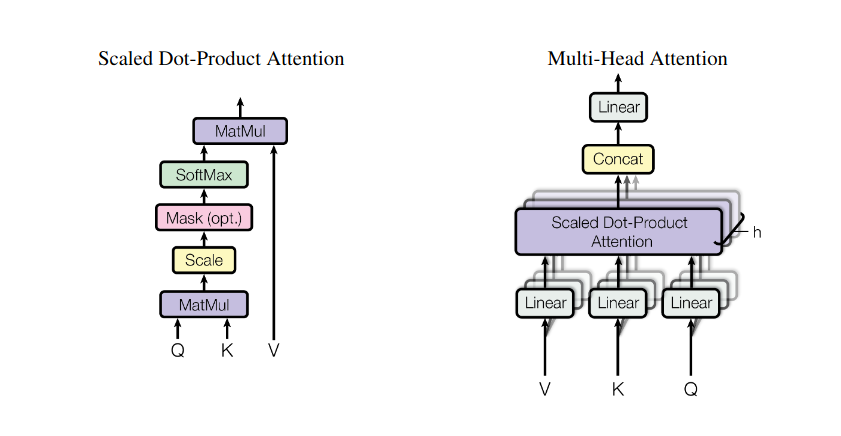

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, no_of_heads):
        super().__init__()
        self.d_model = d_model
        self.no_of_heads = no_of_heads
        self.head_dim = d_model//no_of_heads

        # Weights shape is d_model x d_model
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # (batch_size, seq_len, d_model)
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        Q = Q.view(        # (batch_size, num_heads, seq_len, head_dim)
            batch_size,
            seq_len,
            self.no_of_heads,
            self.head_dim
        ).transpose(1, 2)
        
        
        K = K.view(        # (batch_size, num_heads, seq_len, head_dim)
            batch_size,
            seq_len,
            self.no_of_heads,
            self.head_dim
        ).transpose(1, 2)
        
        
        V = V.view(        # (batch_size, num_heads, seq_len, head_dim)
            batch_size,
            seq_len,
            self.no_of_heads,
            self.head_dim
        ).transpose(1, 2)
        

        ### MATMUL ###
        scores = torch.matmul(
            Q,                      # (batch_size, num_heads, seq_len, head_dim)
            K.transpose(-2, -1)     # (batch_size, num_heads, head_dim, seq_len)
        )
        
    
        ### SCALE ###
        scores = scores / math.sqrt(self.head_dim) # (batch_size, num_heads, seq_len, seq_len)


        ### SOFTMAX ###
        attention = torch.softmax(scores, dim=-1)
        
        ### MATMUL ###
        output = torch.matmul(
            attention,              # (batch_size, num_heads, seq_len, seq_len)
            V                       # (batch_size, num_heads, seq_len, head_dim)
        )                           # (batch_size, num_heads, seq_len, head_dim)

        ### CONCAT ###
        output = output.transpose(1, 2).contiguous() # (batch_size, seq_len, num_heads, head_dim)
        
        output = output.view(batch_size, seq_len, self.d_model) # (batch_size, seq_len, d_model)

        ### LINEAR ###
        output = self.fc(output)

        return output

## Positionwise Feed forward Network
```
Everything until here are Linear Operations only. Without adding non-linear functions the model cannot learn complex non-linear 
relationships. FFN introduces non-linearity. 

In [10]:
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))

    def forward(self, x):
        x = self.ffn(x)
        return x

## Encoder Block 
```
Combining all components like MultiHead Attention, Position-wise FFN and Add & Norm.
As specified in the Model Architecture
```

In [11]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, ff_dim, num_head):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, no_of_heads)
        self.ffn = PositionwiseFFN(d_model, d_ff)

        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.1)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        a = self.attention(x)
        x = x + self.dropout1(a)
        x = self.layernorm1(x)
        ff_output = self.ffn(x)
        x = self.dropout2(ff_output) + x
        x = self.layernorm2(x)
        return x

## Encoder-only Transformer Architecture

```
We combined the input embedding ( projected embeddings), postional encoders and stack of multiple encoder blocks.
It returns the context-aware embeddings

In [12]:
class Transformer(nn.Module):
    def __init__(self, d_model, input_features, max_len, num_layers, output_dim):
        super().__init__()
        self.input_embedding = InputProjection(input_features, d_model)
        self.position_encoding = SinusoidalEncoding(max_len, d_model) 
        self.encoder_blocks = nn.ModuleList([ EncoderBlock(d_model, d_ff, no_of_heads) for _ in range(num_layers) ])

        self.head = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_embedding(x)
        x = self.position_encoding(x)
        for encoder in self.encoder_blocks:
            x = encoder(x)

        x = x.mean(dim=1)
        x = self.head(x)

        return x

with l_r = 1e-4 and weight decay = 1e-3 at 20th epoch -> 0.159

with l_r = 1e-4 and no weight decay at 20 epoch EPOCH 19 --- 0.14093860721058835

both hidden dim

In [13]:
model = Transformer(d_model, input_features, seq_len, no_of_encoder_layers, output_len)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.HuberLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)
epochs = 250

In [15]:
def validate_model(model, dl, criterion):
    running_loss = 0
    model.eval()
    
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
    
            y_hat = model(X)
            loss = criterion(y_hat, y)
    
            running_loss += loss.item()

    return running_loss/len(dl)

In [16]:
def evaluate_metrics (model, optimizer, dl):
    mse_loss_function = nn.MSELoss()
    mae_loss_function = nn.L1Loss()

    predictions = []
    targets = []
    
    model.eval()
    
    running_mse_loss = 0
    running_mae_loss = 0
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
            
            y_hat = model(X)
    
            predictions.append(y_hat.cpu().numpy())
            targets.append(y.cpu().numpy())
    
            running_mse_loss += mse_loss_function(y_hat, y).item()
            running_mae_loss += mae_loss_function(y_hat, y).item()

    y_true = np.concatenate(targets, axis=0)
    y_pred = np.concatenate(predictions, axis=0)

    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - rss / tss
    
    loss_mse = running_mse_loss/len(dl)
    loss_mae = running_mae_loss/len(dl)
    
    return r2, loss_mae, loss_mse

In [17]:
def train_model(model, train_dl, val_dl, criterion, optimizer, epochs):
    val_loss = []
    train_loss = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for X, y in train_dl:
            X = X.to(device)
            y = y.to(device)
        
            optimizer.zero_grad()
            
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
        
            running_loss += loss.item()
            
            optimizer.step()
            
        cur_val_loss = validate_model(model, val_dl, criterion)
        val_loss.append(cur_val_loss)

        cur_train_loss = running_loss/len(train_dl)
        train_loss.append(cur_train_loss)
        
        print("EPOCH", epoch, "|" , "Validation Loss", cur_val_loss, "|", "Training Loss", cur_train_loss)
    return val_loss, train_loss
    

In [ ]:
val_losses, train_losses = train_model(model, train_dl, val_dl, criterion, optimizer, epochs)

r2, mae, mse = evaluate_metrics(model, optimizer, test_dl)

EPOCH 0 | Validation Loss 0.38665607805345575 | Training Loss 0.4110167347115283
EPOCH 1 | Validation Loss 0.2240139203864375 | Training Loss 0.255856309120627
EPOCH 2 | Validation Loss 0.1805976946515585 | Training Loss 0.1219346003185761
EPOCH 3 | Validation Loss 0.13394463013589772 | Training Loss 0.1075508855721686
EPOCH 4 | Validation Loss 0.12849550130564014 | Training Loss 0.10171318103953898
EPOCH 5 | Validation Loss 0.12101650338473857 | Training Loss 0.0973140577082861
EPOCH 6 | Validation Loss 0.11907036016920423 | Training Loss 0.09366605687652649
EPOCH 7 | Validation Loss 0.11667628243589907 | Training Loss 0.09041239838507797
EPOCH 8 | Validation Loss 0.11542061331614949 | Training Loss 0.08749877185973946
EPOCH 9 | Validation Loss 0.11414020238261596 | Training Loss 0.08526700320248405


In [ ]:
print("="*5, "R2 Score", r2, "-", "MAE", mae, "MSE", mse, "="*5)